# ResNet-50 | Training from Scratch
Multi-label clothing classification - 5 classes  
Loss: BCEWithLogitsLoss + pos_weight | Init: Kaiming (PyTorch default) | Threshold: 0.5

## 1. Configuration

In [ ]:
import os, glob, pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


BASE_DIR = '/kaggle/input/datasets/fashion/processed'

TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train', 'images')
VAL_IMG_DIR   = os.path.join(BASE_DIR, 'validation', 'images')

print(f'Dataset root : {BASE_DIR}')
print(f'Train images : {TRAIN_IMG_DIR}')
print(f'Val   images : {VAL_IMG_DIR}')


BATCH_SIZE          = 64
NUM_CLASSES         = 5
NUM_EPOCHS          = 30      
LR                  = 1e-3
WEIGHT_DECAY        = 1e-4
PATIENCE            = 5       
THRESHOLD           = 0.5
CKPT                = '/kaggle/working/resnet50_scratch_best.pth'
CLASS_NAMES         = ['short_sleeve_top', 'trousers', 'shorts',
                        'long_sleeve_top', 'skirt']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {device}')

## 2. Load Labels

In [ ]:
with open(os.path.join(BASE_DIR, 'train_labels.pkl'), 'rb') as f:
    train_labels = pickle.load(f)  
with open(os.path.join(BASE_DIR, 'val_labels.pkl'), 'rb') as f:
    val_labels = pickle.load(f)

train_arr = np.array(list(train_labels.values()))  

print(f'Train: {len(train_labels):,}  |  Val: {len(val_labels):,}')
print('\nClass positives in train:')
for i, c in enumerate(CLASS_NAMES):
    p = int(train_arr[:, i].sum())
    print(f'  {c:<20}: {p:>6}  ({p/len(train_arr)*100:.1f}%)')

Train: 144,174  |  Val: 23,741

Class positives in train:
  short_sleeve_top    :  70586  (49.0%)
  trousers            :  54969  (38.1%)
  shorts              :  36332  (25.2%)
  long_sleeve_top     :  35751  (24.8%)
  skirt               :  30625  (21.2%)


## 3. Dataset & DataLoader
Transforms are necessary: ResNet-50 requires 224×224 fixed input.  
Train: random crop + horizontal flip (standard augmentation, nothing excessive).  
Val: deterministic resize + centre crop.

In [3]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class FashionDataset(Dataset):
    def __init__(self, labels_dict, img_root, transform=None):
        self.labels    = labels_dict
        self.filenames = list(labels_dict.keys())
        self.transform = transform
        self.img_root  = img_root

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, i):
        fname = self.filenames[i]
        img   = Image.open(os.path.join(self.img_root, fname)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[fname], dtype=torch.float32)
        return img, label

_mean = [0.485, 0.456, 0.406]
_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=_mean, std=_std),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=_mean, std=_std),
])

train_ds = FashionDataset(train_labels, TRAIN_IMG_DIR, train_tf)
val_ds   = FashionDataset(val_labels,   VAL_IMG_DIR,   val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
xb, yb = next(iter(train_loader))
print('Batch image shape:', xb.shape)
print('Batch label shape:', yb.shape)

Train batches: 2253 | Val batches: 371
Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64, 5])


## 4. Model
`weights=None` → Kaiming init (PyTorch default for ResNet conv layers).  
FC replaced: 2048 → 5 (one logit per class). No sigmoid here - it lives inside BCEWithLogitsLoss.

In [4]:
model = resnet50(weights=None)
model.fc = nn.Linear(2048, NUM_CLASSES)
nn.init.kaiming_normal_(model.fc.weight, mode='fan_out', nonlinearity='relu')
nn.init.constant_(model.fc.bias, 0.0)
model = model.to(device)

print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable params: 23,518,277


## 5. Loss, Optimizer & Scheduler
`pos_weight[i] = neg_i / pos_i` - correct formula for BCEWithLogitsLoss.  
This up-weights positive samples for minority classes (skirt pos_weight ≈ 3.71).

In [ ]:
pos        = train_arr.sum(axis=0)                    
neg        = len(train_arr) - pos
pos_weight = torch.tensor(neg / pos, dtype=torch.float32).to(device)

print('pos_weight per class:')
for name, w in zip(CLASS_NAMES, pos_weight.cpu().tolist()):
    print(f'  {name:<20}: {w:.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

pos_weight per class:
  short_sleeve_top    : 1.043
  trousers            : 1.623
  shorts              : 2.968
  long_sleeve_top     : 3.033
  skirt               : 3.708


## 6. Evaluation Function

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

def evaluate(model, loader, criterion=None):
    model.eval()
    probs_list, labels_list = [], []
    total_vloss = 0.0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs_d, lbls_d = imgs.to(device), lbls.to(device)
            logits = model(imgs_d)
            probs_list.append(torch.sigmoid(logits).cpu().numpy())
            labels_list.append(lbls.numpy())
            if criterion:
                total_vloss += criterion(logits, lbls_d).item() * imgs.size(0)

    probs  = np.vstack(probs_list)    
    labels = np.vstack(labels_list)   
    preds  = (probs >= THRESHOLD).astype(int)

    per_class = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = int(((preds[:,i]==1) & (labels[:,i]==1)).sum())
        fp = int(((preds[:,i]==1) & (labels[:,i]==0)).sum())
        tn = int(((preds[:,i]==0) & (labels[:,i]==0)).sum())
        fn = int(((preds[:,i]==0) & (labels[:,i]==1)).sum())
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        f1   = 2*prec*rec / (prec + rec + 1e-8)
        auc  = roc_auc_score(labels[:,i], probs[:,i])
        ap   = average_precision_score(labels[:,i], probs[:,i])  # AP for mAP
        per_class[cls] = dict(TP=tp, FP=fp, TN=tn, FN=fn,
                               Precision=prec, Recall=rec, F1=f1, AUC=auc, AP=ap)

    macro_f1 = float(np.mean([v['F1'] for v in per_class.values()]))
    ttp = sum(v['TP'] for v in per_class.values())
    tfp = sum(v['FP'] for v in per_class.values())
    tfn = sum(v['FN'] for v in per_class.values())
    mp  = ttp / (ttp + tfp + 1e-8)
    mr  = ttp / (ttp + tfn + 1e-8)
    micro_f1 = 2*mp*mr / (mp + mr + 1e-8)

    
    hamming_acc = float((preds == labels).mean())
    exact_match = float((preds == labels).all(axis=1).mean())
    mAP = float(np.mean([v['AP'] for v in per_class.values()]))

    val_loss = total_vloss / len(loader.dataset) if criterion else None
    return per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, probs, labels, val_loss

## 7. Training

In [ ]:
history = {'train_loss':[], 'val_loss':[], 'macro_f1':[], 'micro_f1':[]}
best_macro_f1  = 0.0
patience_count = 0
scaler = torch.amp.GradScaler('cuda')
for epoch in range(1, NUM_EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────
    model.train()
    run_loss = 0.0
    for imgs, lbls in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            loss = criterion(model(imgs), lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        run_loss += loss.item() * imgs.size(0)
    train_loss = run_loss / len(train_ds)


    per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, _, _, val_loss = evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['macro_f1'].append(macro_f1)
    history['micro_f1'].append(micro_f1)

    print(f'Ep {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | '
      f'macro_f1={macro_f1:.4f} | micro_f1={micro_f1:.4f} | '
      f'hamming={hamming_acc:.4f} | mAP={mAP:.4f}')

    scheduler.step(macro_f1)
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        patience_count = 0
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'macro_f1'         : macro_f1,
            'micro_f1'         : micro_f1,
            'per_class_metrics': per_class,
        }, CKPT)
        print(f'  ✓ Best model saved (macro-F1={macro_f1:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).')
            break

print(f'\nBest val macro-F1: {best_macro_f1:.4f}')

Epoch 1/30:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 01 | train_loss=1.2215 | val_loss=1.3945 | macro_f1=0.3930 | micro_f1=0.4301 | hamming=0.5861 | mAP=0.3987
  ✓ Best model saved (macro-F1=0.3930)


Epoch 2/30:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 02 | train_loss=0.9648 | val_loss=0.9022 | macro_f1=0.4895 | micro_f1=0.5021 | hamming=0.5826 | mAP=0.4569
  ✓ Best model saved (macro-F1=0.4895)


Epoch 3/30:   0%|          | 0/2253 [00:00<?, ?it/s]

...

Ep 05 | train_loss=0.9229 | val_loss=0.9210 | macro_f1=0.4058 | micro_f1=0.4910 | hamming=0.6655 | mAP=0.4393


Epoch 6/30:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 06 | train_loss=0.8922 | val_loss=1.0014 | macro_f1=0.4698 | micro_f1=0.4756 | hamming=0.5996 | mAP=0.4596


Epoch 7/30:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 07 | train_loss=0.8538 | val_loss=0.9783 | macro_f1=0.4864 | micro_f1=0.4895 | hamming=0.5955 | mAP=0.4714

Early stopping at epoch 7 (no improvement for 5 epochs).

Best val macro-F1: 0.4895


## 8. Final Evaluation (best checkpoint)

In [8]:
ckpt = torch.load(CKPT, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, all_probs, all_labels, _ = \
    evaluate(model, val_loader, criterion)

print('=' * 88)
print(f'  ResNet-50 from Scratch  |  Best epoch: {ckpt["epoch"]}  |  Threshold: {THRESHOLD}')
print('=' * 88)
print(f'{"Class":<22} {"TP":>7} {"FP":>7} {"TN":>7} {"FN":>7} '
      f'{"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7} {"AP":>7}')
print('-' * 88)
for cls in CLASS_NAMES:
    m = per_class[cls]
    print(f'{cls:<22} {m["TP"]:>7} {m["FP"]:>7} {m["TN"]:>7} {m["FN"]:>7} '
          f'{m["Precision"]:>7.4f} {m["Recall"]:>7.4f} {m["F1"]:>7.4f} '
          f'{m["AUC"]:>7.4f} {m["AP"]:>7.4f}')
print('-' * 88)
print(f'{"Macro-F1":<22} {macro_f1:>7.4f}')
print(f'{"Micro-F1":<22} {micro_f1:>7.4f}')
print(f'{"mAP":<22} {mAP:>7.4f}')
print(f'{"Hamming Accuracy":<22} {hamming_acc:>7.4f}')
print(f'{"Exact Match":<22} {exact_match:>7.4f}')

  ResNet-50 from Scratch  |  Best epoch: 2  |  Threshold: 0.5
Class                       TP      FP      TN      FN    Prec     Rec      F1     AUC      AP
----------------------------------------------------------------------------------------
short_sleeve_top          8430    6105    5265    3941  0.5800  0.6814  0.6266  0.6041  0.6114
trousers                  4694    2246   12001    4800  0.6764  0.4944  0.5713  0.7280  0.6772
shorts                    2957    8306   11302    1176  0.2625  0.7155  0.3841  0.7009  0.3164
long_sleeve_top           3507    7681   10144    2409  0.3135  0.5928  0.4101  0.6196  0.3299
skirt                     5389   11771    5471    1110  0.3140  0.8292  0.4556  0.6100  0.3493
----------------------------------------------------------------------------------------
Macro-F1                0.4895
Micro-F1                0.5021
mAP                     0.4569
Hamming Accuracy        0.5826
Exact Match             0.0697


## 9. ROC Curves

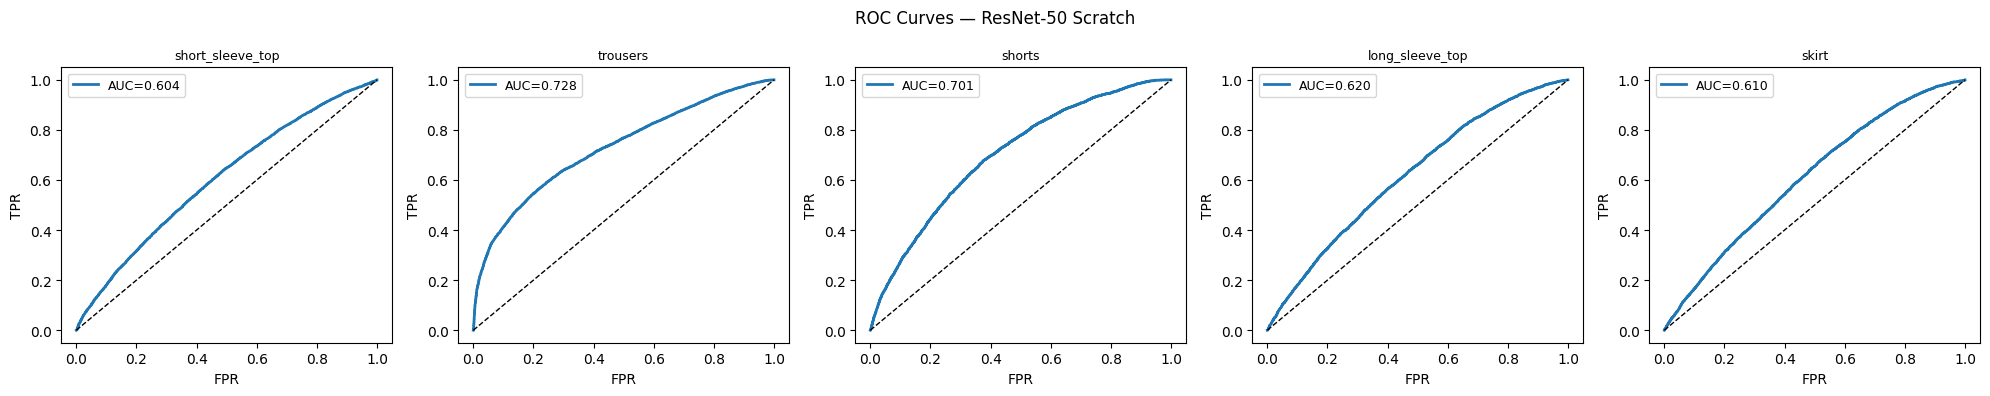

In [9]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, label=f'AUC={per_class[cls]["AUC"]:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(cls, fontsize=9)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=9)
plt.suptitle('ROC Curves — ResNet-50 Scratch', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Training Curves

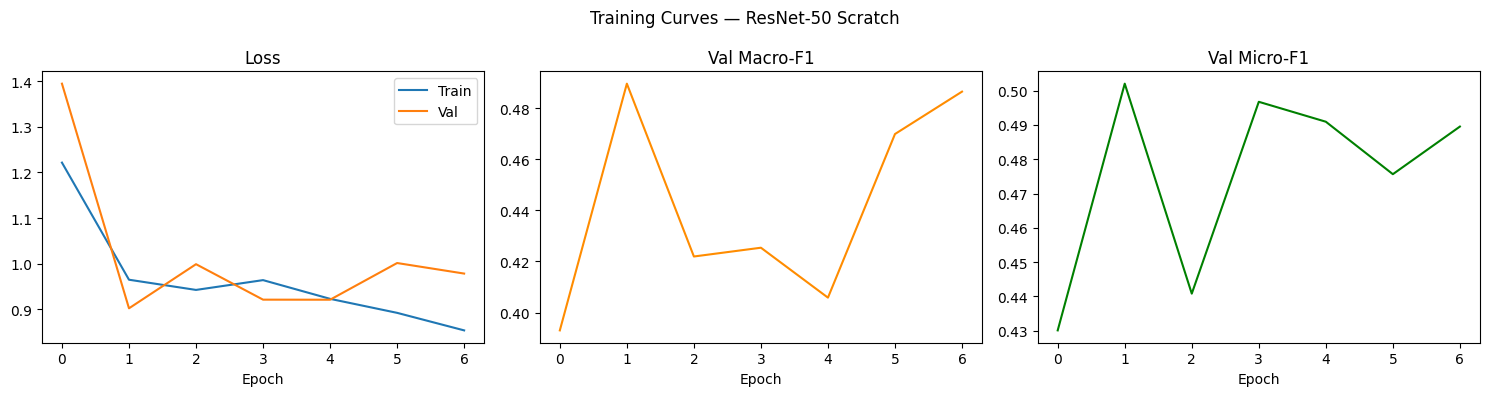

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['macro_f1'], color='darkorange')
axes[1].set_title('Val Macro-F1'); axes[1].set_xlabel('Epoch')

axes[2].plot(history['micro_f1'], color='green')
axes[2].set_title('Val Micro-F1'); axes[2].set_xlabel('Epoch')

plt.suptitle('Training Curves — ResNet-50 Scratch', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/curves_scratch.png', dpi=150, bbox_inches='tight')
plt.show()